In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
s_firm3d = np.load('s_compare_FIRM3D.npy',allow_pickle=True)
omega_firm3d = np.load('omega_compare_FIRM3D.npy',allow_pickle=True)
omega_desc = np.load('G1600_omega_KEs.npy',allow_pickle=True)
rhos_desc = np.linspace(0.1,0.9,5)**0.5

rhos_firm3d = s_firm3d**0.5 # rho = sqrt(s)

KE_frac = np.array([1e-5,1e-4,1e-3,1e-2,1e-1,4e-1,7e-1,1])

[array([0.2864939 , 0.29158267, 0.293729  , 0.31363264, 0.32010729,
        0.4504918 , 0.46622587, 0.49080114, 0.54554201, 0.55471344,
        0.63670241, 0.64736814, 0.69548354, 0.7468705 , 0.75457598,
        0.84885933, 0.85042008, 0.87823468, 0.93200865, 0.93281012])
 array([0.09393306, 0.09398488, 0.10011105, 0.10074158, 0.10287499,
        0.28450049, 0.28891805, 0.29416344, 0.31532546, 0.31955966,
        0.46084153, 0.47527063, 0.48604647, 0.53848909, 0.55618008,
        0.64570914, 0.66275808, 0.67194109, 0.73586292, 0.76085668,
        0.86174323, 0.86370228, 0.86846394, 0.91184051, 0.93000949])
 array([0.09400278, 0.0944752 , 0.09978201, 0.10062135, 0.10298261,
        0.28446908, 0.28934445, 0.29488036, 0.31477666, 0.32070418,
        0.46151346, 0.47636623, 0.48735095, 0.53261946, 0.55353378,
        0.64755685, 0.66170309, 0.67343168, 0.72478781, 0.76000581,
        0.86357843, 0.86547037, 0.86857409, 0.91194507, 0.93396561])
 array([0.09303121, 0.09658497, 0.10207256, 0

In [3]:
# Average over zeta/field line for firm3d
omega_firm3d_avg = np.zeros((len(KE_frac),len(rhos_desc)))
nzeta = 5
for k in range(0,len(KE_frac)):
    for i in range(0,len(rhos_desc)):
        omega_firm3d_avg[k,i] = np.mean(omega_firm3d[k][i*nzeta:i*nzeta+nzeta])
# note there may be nans. Here there are nans at i_KE=(0,5,6,7), i_s=(4)

/opt/homebrew/Caskroom/miniconda/base/envs/DESC_fork_08282025/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniconda/base/envs/DESC_fork_08282025/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [14]:
# Calculate difference
diff_codes = abs(abs(omega_firm3d_avg) - abs(omega_desc.T))
diff_codes_norm = diff_codes / (abs(omega_firm3d_avg))

In [ ]:
print(omega_firm3d_avg)
print(omega_desc)

[[-4.61719738e-04 -2.32911911e-04 -1.96871808e-04]
 [-9.86809149e-03 -1.46496597e-03 -7.36611963e-04]
 [-3.11195764e-02 -4.62938311e-03 -2.32640300e-03]
 [-9.54232127e-02 -1.46387700e-02 -7.36354387e-03]
 [-2.84175661e-01 -4.63107113e-02 -2.33118448e-02]]
[[1.00980980e-05 1.34740860e-06 7.71706180e-07 5.73445376e-07
  4.70076698e-07]
 [1.00980980e-04 1.34740860e-05 7.71706180e-06 5.73445376e-06
  4.70076698e-06]
 [1.00980980e-03 1.34740860e-04 7.71706180e-05 5.73445376e-05
  4.70076698e-05]
 [1.00980980e-02 1.34740860e-03 7.71706180e-04 5.73445376e-04
  4.70076698e-04]
 [1.00980980e-01 1.34740860e-02 7.71706180e-03 5.73445376e-03
  4.70076698e-03]]


/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_15507/3754677755.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=14)
/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_15507/3754677755.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=14)


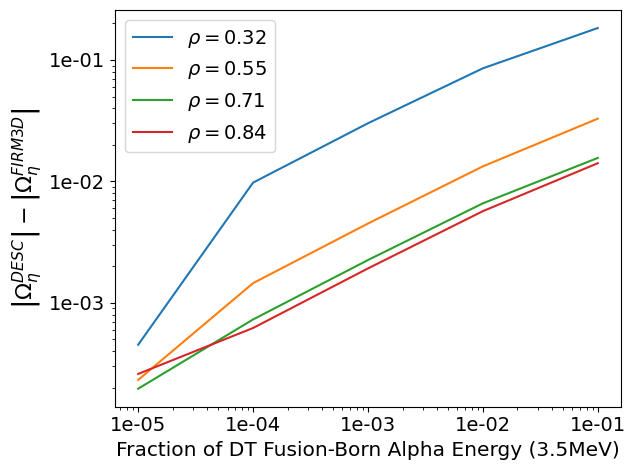

In [52]:
fig,ax = plt.subplots()
i=0
for rho in rhos_firm3d:
    ax.loglog(KE_frac[0:5],diff_codes[0:5,i],label=r'$\rho = $'+str(round(rhos_desc[i],2)))
    i+=1
    if i==4:
        break

print(omega_firm3d_avg[0:5,0:3])
print(omega_desc.T[0:5,:])
# plt.rcParams['axes.formatter.useoffset'] = False
# plt.rcParams['axes.formatter.use_mathtext'] = True
# plt.rcParams['axes.formatter.limits'] = (-1, 1)


ax.legend(fontsize=14)
ax.set_xlabel("Fraction of DT Fusion-Born Alpha Energy (3.5MeV)",fontsize=14.5)
ax.set_ylabel(r"$\left|\Omega_\eta^{DESC}\right| - \left|\Omega_\eta^{FIRM3D}\right|$",fontsize=16)
ax.set_xticklabels(ax.get_xticks(), fontsize=14)
ax.set_yticklabels(ax.get_yticks(), fontsize=14)
plt.tight_layout()

# from matplotlib.ticker import ScalarFormatter

# ax.xaxis.set_major_formatter(ScalarFormatter())
# ax.yaxis.set_major_formatter(ScalarFormatter())


from matplotlib.ticker import FuncFormatter

def sci_notation(x, pos):
    return f'{x:.0e}'  # e.g., 1e-3, 2e+1, etc
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))
ax.yaxis.set_major_formatter(FuncFormatter(sci_notation))

# ax.ticklabel_format(style='sci', axis='both', scilimits=(-1, 1))

plt.savefig('codes_difference.pdf')

